<a href="https://colab.research.google.com/github/Samiksha22911/AIML-LAB-EXPERIMENTS/blob/main/Logistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Experiment 3: Logistic Regression
Dataset: Breast Cancer dataset (real-world, sklearn / UCI source, 150-row sample)

- Implements logistic regression for binary classification
- Evaluates using accuracy, precision, recall, ROC AUC
- Visualizes a decision boundary using the two most informative features
"""

'\nExperiment 3: Logistic Regression\nDataset: Breast Cancer dataset (real-world, sklearn / UCI source, 150-row sample)\n\n- Implements logistic regression for binary classification\n- Evaluates using accuracy, precision, recall, ROC AUC\n- Visualizes a decision boundary using the two most informative features\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

In [3]:
# 1. Load dataset

df = pd.read_csv("dataset_breast_cancer.csv")
print("Dataset shape:", df.shape)
print(df["target"].value_counts())  # 0 = malignant, 1 = benign

X = df.drop(columns=["target"])
y = df["target"].values

Dataset shape: (150, 31)
target
1    94
0    56
Name: count, dtype: int64


In [4]:
# 2. Train/test split + scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# 3. Train model (all features)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

In [6]:
# 4. Evaluate

print(f"\nAccuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.3f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Malignant", "Benign"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.close()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", label=f"ROC (AUC = {roc_auc_score(y_test, y_proba):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.close()


Accuracy:  1.000
Precision: 1.000
Recall:    1.000
F1-score:  1.000
ROC AUC:   1.000



Saved plots -> confusion_matrix.png, roc_curve.png, decision_boundary.png


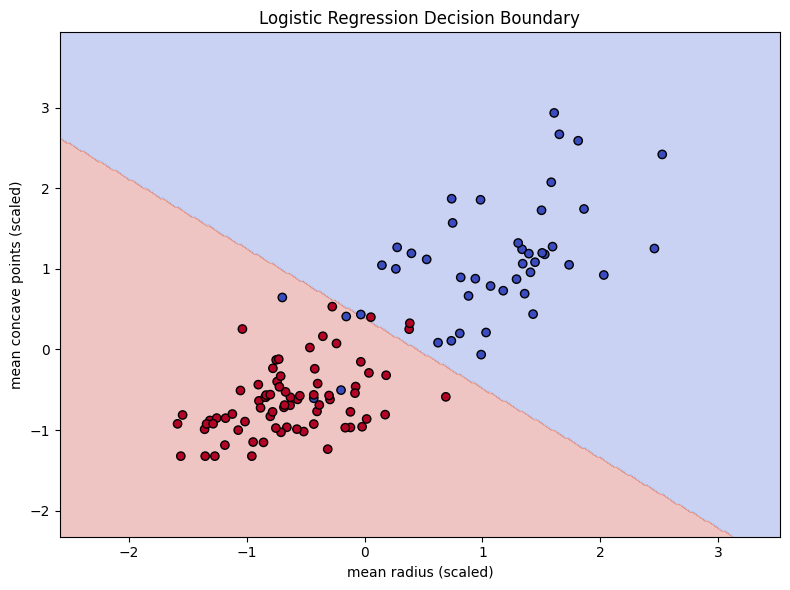

In [7]:
# 5. Decision boundary using 2 most informative features

feat_x, feat_y = "mean radius", "mean concave points"
X2 = df[[feat_x, feat_y]].values
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y
)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

model2 = LogisticRegression(max_iter=5000)
model2.fit(X2_train_s, y2_train)

x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap="coolwarm",
            edgecolor="k", label="Train")
plt.xlabel(f"{feat_x} (scaled)")
plt.ylabel(f"{feat_y} (scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=150)
print("\nSaved plots -> confusion_matrix.png, roc_curve.png, decision_boundary.png")
plt.show()